# Installation + Quickstart

To install alabi, clone it from the git repo:
```bash
git clone https://github.com/jbirky/alabi
cd alabi
python setup.py install
```

### Step 1

Import python modules:

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from alabi.core import SurrogateModel

from matplotlib import rcParams
# rcParams['font.family'] = 'serif'
# rcParams['text.usetex'] = True

random_state = 7
np.random.seed(random_state)

### Step 2

Define the test function and the bounds for the input space. For example:

In [2]:
def test1d_fn(x):
    return np.sin(5 * x) * (1 - np.tanh(x**2))

bounds = [(-1, 1)]

### Step 3

Initialize the surrogate model, specifying the function to train on, the bounds of the input space, and directory where the results will be saved:

In [3]:
sm = SurrogateModel(lnlike_fn=test1d_fn, bounds=bounds, savedir=f"results/test1d", random_state=random_state)

### Step 4

Initialize the gaussian process surrogate model by specifying a kernel. In this example we'll use a squared exponential kernel:

$ k(x, x') = \sigma_f^2 \exp\left(-\frac{(x - x')^2}{2\ell^2}\right) $

where $ k(x, x') $ is the kernel function, $ \sigma_f^2 $ is the amplitude hyperparameter, $ \ell $ is the length scale hyperparameter, and $ x $ and $ x' $ are input points.

In [4]:
sm.init_samples(ntrain=10)
sm.init_gp(kernel="ExpSquaredKernel", fit_amp=True, fit_mean=True, hyperopt_method="ml", overwrite=True)

Initialized GP with squared exponential kernel.
Successfully initialized GP on attempt 1


Optimizing GP: 100%|██████████| 3/3 [00:00<00:00, 54.26it/s]

Initial -logL: 	 0.5847 | 	 Regularization: 1.6234 | 	 Total: 2.2081
Final -logL: 	 -8.6579 | 	 Regularization: 1.3110 | 	 Total: -7.3469 
13 iterations | Success: True | Message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH 



### Step 5

Improve the surrogate model fit by iteratively selecting new training points using active learning:

In [5]:
sm.active_train(niter=30, algorithm="bape", gp_opt_freq=10)

Running 30 active learning iterations using bape...


 33%|███▎      | 10/30 [00:00<00:00, 72.83it/s]

Initial -logL: 	 -57.3958 | 	 Regularization: 1.3110 | 	 Total: -56.0848
Final -logL: 	 -59.0394 | 	 Regularization: 1.3352 | 	 Total: -57.7042 
18 iterations | Success: True | Message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH 

Train MSE: 9.298666599099183e-10


 67%|██████▋   | 20/30 [00:00<00:00, 75.69it/s]

Initial -logL: 	 -121.3295 | 	 Regularization: 1.3352 | 	 Total: -119.9943
Final -logL: 	 -121.3499 | 	 Regularization: 1.3367 | 	 Total: -120.0132 
17 iterations | Success: True | Message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH 

Train MSE: 2.79227309296412e-09


100%|██████████| 30/30 [00:02<00:00, 13.53it/s]

Initial -logL: 	 -185.4210 | 	 Regularization: 1.3367 | 	 Total: -184.0843
Final -logL: 	 -185.4270 | 	 Regularization: 1.3376 | 	 Total: -184.0893 
6 iterations | Success: True | Message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH 

Train MSE: 2.5884057559963692e-09
Caching model to results/test1d/surrogate_model...


### Step 6

Run Markov Chain Monte Carlo (MCMC) sampler using either the `emcee` package:

In [6]:
sm.run_emcee(nwalkers=4, nsteps=int(5e4))

Initializing emcee with self.surrogate_log_likelihood surrogate model as likelihood.
No prior_fn specified. Defaulting to uniform prior with bounds [[-1  1]]
Running emcee with 4 walkers for 50000 steps on 1 cores...

Run 1: Need 10000 more samples...


100%|██████████| 50000/50000 [00:51<00:00, 973.36it/s] 


burn-in estimate: 118
thin estimate: 29

Run 1 complete: 6880 samples
Total accumulated samples: 6880

Run 2: Need 3120 more samples...


100%|██████████| 50000/50000 [00:50<00:00, 981.16it/s] 


burn-in estimate: 105
thin estimate: 26

Run 2 complete: 7676 samples
Total accumulated samples: 14556

Combined 2 runs into 14556 total samples
Total samples: 14556
Mean acceptance fraction: 0.694
Mean autocorrelation time: 52.681 steps
Caching model to results/test1d/surrogate_model...
Saving final emcee samples to results/test1d/emcee_samples_final_surrogate_iter_30.npz ...


In [7]:
sm.run_dynesty()

Initializing dynesty with self.surrogate_log_likelihood surrogate model as likelihood.
Initialized dynesty DynamicNestedSampler.
Running dynesty with 50 live points on 1 cores...

Run 1: Need 10000 more samples...


10103it [00:09, 1057.98it/s, batch: 78 | bound: 0 | nc: 1 | ncall: 22538 | eff(%): 44.827 | loglstar:   -inf <  0.909 <  0.295 | logz:  0.127 +/-  0.022 | stop:  0.999]


Run 1 complete: 10103 samples, logZ = 0.127
Total accumulated samples: 10103
Caching model to results/test1d/surrogate_model...
Saved dynesty samples to results/test1d/dynesty_samples_final_surrogate_iter_30.npz


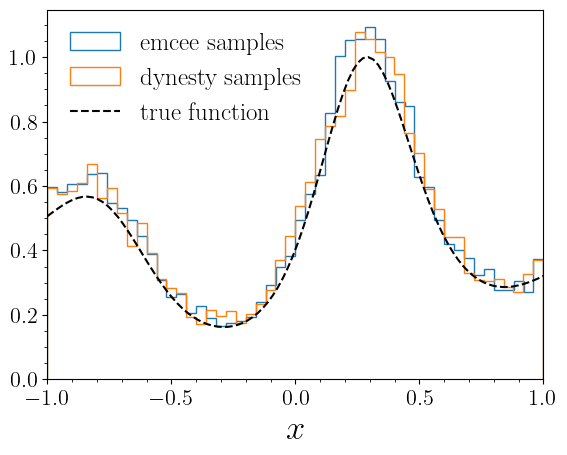

In [8]:
xgrid = np.linspace(bounds[0][0], bounds[0][1], 100)
ygrid = np.exp(test1d_fn(xgrid))

plt.hist(sm.emcee_samples.T[0], bins=50, histtype='step', density=True, label="emcee samples")
plt.hist(sm.dynesty_samples.T[0], bins=50, histtype='step', density=True, label="dynesty samples")
plt.plot(xgrid, ygrid/max(ygrid), label="true function", color="k", linestyle="--")
plt.xlabel("$x$", fontsize=25)
plt.xlim(*bounds)
plt.legend(loc="upper left", fontsize=18, frameon=False)
plt.minorticks_on()
plt.show()